# Equal-Weight S&P 500 Investing Algorithm

This algorithm constructs an **equal-weight portfolio** from the S&P 500, where each position receives the same dollar allocation regardless of market capitalisation. Unlike cap-weighted indices (where a few mega-caps dominate), equal weighting provides balanced exposure across all holdings.

**Inputs:** S&P 500 stock universe, portfolio value  
**Outputs:** Number of shares to purchase for each position

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
import matplotlib.pyplot as plt

## 2. Load Stock Universe

Load a curated list of 50 S&P 500 stocks spanning all major sectors.

In [2]:
tickers = pd.read_csv("sp500_stocks.csv")
print(f"Loaded {len(tickers)} stocks across {tickers['Sector'].nunique()} sectors")
tickers.head(10)

Loaded 50 stocks across 9 sectors


,Ticker,Company Name,Sector
0,AAPL,Apple Inc.,Technology
1,MSFT,Microsoft Corporation,Technology
2,GOOGL,Alphabet Inc.,Technology
3,AMZN,Amazon.com Inc.,Technology
4,NVDA,NVIDIA Corporation,Technology
5,META,Meta Platforms Inc.,Technology
6,TSLA,Tesla Inc.,Technology
7,AVGO,Broadcom Inc.,Technology
8,CRM,Salesforce Inc.,Technology
9,ADBE,Adobe Inc.,Technology


## 3. Fetch Market Data

Retrieve the latest closing price and market capitalisation for each stock using the Yahoo Finance API. Stocks are then sorted by market cap to select the top 10 largest companies.

In [3]:
def fetch_market_cap(ticker_list):
    """Fetch latest price and market cap for each ticker."""
    data = yf.download(ticker_list, period="1d", group_by="ticker", auto_adjust=False, progress=False)
    
    stocks_data = []
    for ticker in ticker_list:
        latest_price = data[ticker]["Close"].iloc[-1]
        market_cap = yf.Ticker(ticker).info.get("marketCap", "N/A")
        
        stocks_data.append({
            "Ticker": ticker,
            "Market Cap": market_cap,
            "Latest Price": latest_price,
        })
    
    return pd.DataFrame(stocks_data)

tickers_list = tickers["Ticker"].values.tolist()
df = fetch_market_cap(tickers_list)
print(f"Successfully fetched data for {len(df)} stocks")

Successfully fetched data for 50 stocks


## 4. Select Top 10 by Market Cap

In [4]:
df = df.sort_values(by="Market Cap", ascending=False)
df = df.head(10)
df.reset_index(inplace=True, drop=True)

df["Market Cap ($B)"] = (df["Market Cap"] / 1e9).round(1)
df[["Ticker", "Latest Price", "Market Cap ($B)"]]

,Ticker,Latest Price,Market Cap ($B)
0,NVDA,192.529999,4663.3
1,AAPL,283.779999,4168.0
2,GOOGL,337.390015,4117.0
3,MSFT,372.970001,2770.6
4,AMZN,232.690002,2503.1
5,AVGO,365.019989,1736.6
6,TSLA,379.709991,1426.1
7,META,550.250000,1396.8
8,LLY,1208.119995,1077.3
9,WMT,115.690002,920.7


## 5. Equal-Weight Portfolio Construction

With a **$500,000 portfolio**, each of the 10 positions receives an equal allocation of $50,000. The number of whole shares to purchase is calculated for each stock.

In [5]:
portfolio_size = 500_000
position_size = portfolio_size / len(df.index)

df["Position Size ($)"] = position_size
df["Shares to Buy"] = df["Latest Price"].apply(
    lambda price: math.floor(position_size / price)
)
df["Allocated ($)"] = (df["Shares to Buy"] * df["Latest Price"]).round(2)

total_allocated = df["Allocated ($)"].sum()
cash_remaining = portfolio_size - total_allocated

print(f"Portfolio Size:    ${portfolio_size:,.2f}")
print(f"Total Allocated:   ${total_allocated:,.2f}")
print(f"Cash Remaining:    ${cash_remaining:,.2f}")
print(f"Positions:         {len(df)}")
print(f"Per Position:      ${position_size:,.2f}")
print()

df[["Ticker", "Latest Price", "Market Cap ($B)", "Shares to Buy", "Allocated ($)"]]

Portfolio Size:    $500,000.00
Total Allocated:   $497,936.14
Cash Remaining:    $2,063.86
Positions:         10
Per Position:      $50,000.00



,Ticker,Latest Price,Market Cap ($B),Shares to Buy,Allocated ($)
0,NVDA,192.529999,4663.3,259,49865.27
1,AAPL,283.779999,4168.0,176,49945.28
2,GOOGL,337.390015,4117.0,148,49933.72
3,MSFT,372.970001,2770.6,134,49977.98
4,AMZN,232.690002,2503.1,214,49795.66
5,AVGO,365.019989,1736.6,136,49642.72
6,TSLA,379.709991,1426.1,131,49742.01
7,META,550.250000,1396.8,90,49522.50
8,LLY,1208.119995,1077.3,41,49532.92
9,WMT,115.690002,920.7,432,49978.08


## 6. Portfolio Visualisation

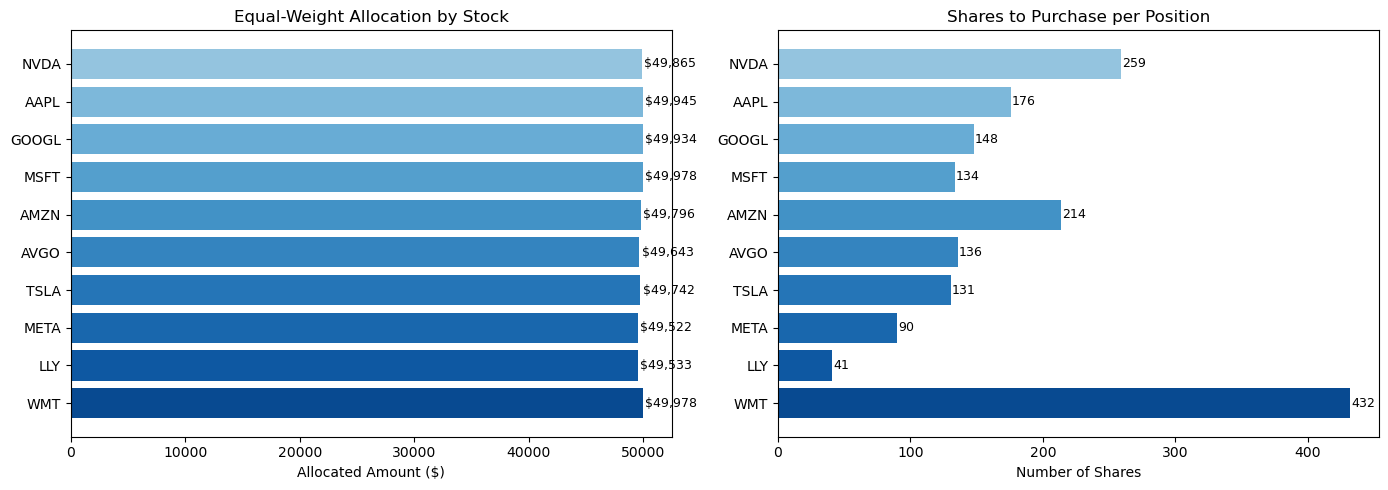

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Allocation bar chart
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))
axes[0].barh(df["Ticker"], df["Allocated ($)"], color=colors)
axes[0].set_xlabel("Allocated Amount ($)")
axes[0].set_title("Equal-Weight Allocation by Stock")
axes[0].invert_yaxis()
for i, v in enumerate(df["Allocated ($)"]):
    axes[0].text(v + 200, i, f"${v:,.0f}", va="center", fontsize=9)

# Shares to buy bar chart
axes[1].barh(df["Ticker"], df["Shares to Buy"], color=colors)
axes[1].set_xlabel("Number of Shares")
axes[1].set_title("Shares to Purchase per Position")
axes[1].invert_yaxis()
for i, v in enumerate(df["Shares to Buy"]):
    axes[1].text(v + 0.5, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("equal_weight_portfolio.png", dpi=150, bbox_inches="tight")
plt.show()